# Data visualization with matplotlib

## Bar plot

In [19]:
# Load data of a final exam and visualize the grade distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset in Excel format into a pandas DataFrame
grade_df = pd.read_excel('../../data/final_grades.xlsx')

In [20]:
# Get the values of the 'Major' 
major_names = grade_df['Major'].unique()

In [21]:
# Add a new colum 'MajorGroup' to group majors into 'IT' and 'Non-IT'
it_majors = ['khmt', 'cntt', 'ttql']

grade_df['MajorGroup'] = \
    grade_df['Major'].apply(lambda x: 'IT' if x in it_majors else 'Non-IT')

# Filter all rows with 'MajorGroup' = 'IT'
it_students_df = grade_df[grade_df['MajorGroup'] == 'IT']


In [22]:
# Computer basic statistics of the data to show on the plot
total_students = len(grade_df)
print(f'Total students: {total_students}')
# Calculate the mean grade
mean_grade = grade_df['Grade'].mean()
print(f'Mean grade: {mean_grade:.2f}')
# Get the median grade
median_grade = grade_df['Grade'].median()
print(f'Median grade: {median_grade:.2f}')
# Calculate the standard deviation of the grades
std = grade_df['Grade'].std()
# Get the minimum and maximum grades
min_grade = grade_df['Grade'].min()
print(f'Minimum grade: {min_grade:.2f}')
max_grade = grade_df['Grade'].max()
print(f'Maximum grade: {max_grade:.2f}')

Total students: 1230
Mean grade: 6.24
Median grade: 6.23
Minimum grade: 2.29
Maximum grade: 10.00


In [23]:
# Create historgram bins of the grades with interval of 0.5
bins = np.arange(0, 10.5, 0.5)
print(bins)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]


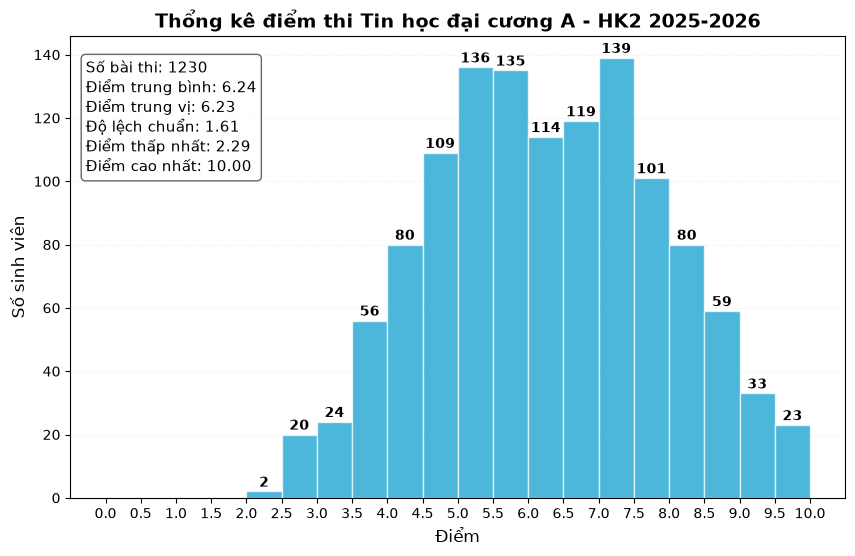

In [24]:
# Crate a histogram of the grades
plt.figure(figsize=(10, 6)) # Set the figure size

counts, edges, patches = plt.hist(grade_df['Grade'], # data to plot
bins=bins,                  # bins for the histogram
color='#0099cc',            # color of the bars
edgecolor='white',
alpha=0.7)              # transparency of the bars

# Add title and labels to the plot
plt.title('PHỔ ĐIỂM BÀI THI THĐC A - TẤT CẢ CÁC NGÀNH', fontsize=16)
plt.xlabel('Điểm', fontsize=14)
plt.ylabel('Số sinh viên', fontsize=14)

# Add count value on top of each bar
for count, edge_left, edge_right in zip(counts, edges[:-1], edges[1:]):
    if count > 0:  # only add text for bars with count > 0
        # calculate the position for the text
        x_pos = (edge_left + edge_right) / 2
        y_pos = count + 0.5  # position the text slightly above the bar
        # print the count value on top of the bar
        plt.text(x_pos, y_pos, str(int(count)), 
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black')

# Add statistics text box to the plot
stats_text = "{}{}\n{}{:.2f}\n{}{:.2f} \
\n{}{:.2f}\n{}{:.2f}\n{}{:.2f}".format("Số bài thi: ", total_students,
                                                    "Điểm trung bình: ", mean_grade,
                                                    "Điểm trung vị: ",  median_grade,
                                                    "Độ lệch chuẩn: ",std,
                                                    "Điểm thấp nhất: ",min_grade,
                                                    "Điểm cao nhất: " ,max_grade )


plt.gca().text(
    0.02, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)


bin_interval = 0.5
bins = np.arange(0, 10 + bin_interval, bin_interval)
bin_labels = [str(bins[i]) + '-' + str(bins[i+1]) for i in range(len(bins)-1)]

# Customize the chart
plt.title("Thổng kê điểm thi Tin học đại cương A - HK2 2025-2026", fontsize=14, weight='bold')
plt.xlabel("Điểm", fontsize=12)
plt.ylabel("Số sinh viên", fontsize=12)
# plt.xticks(bin_labels, rotation=90)
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.1)

# Display the plot 
# plt.tight_layout()
plt.savefig('figs/THDC-Grade-Stats.png') 
plt.show()

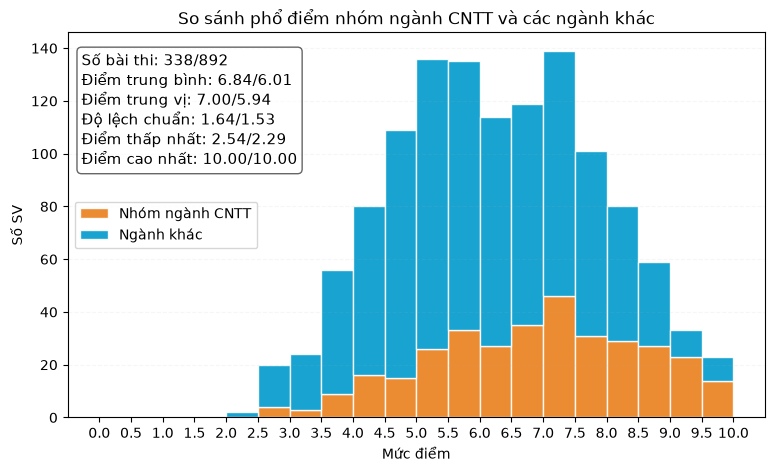

In [25]:
# Filter grades of IT group
grades_cntt = grade_df[grade_df['MajorGroup'] == 'IT']
# Filter grades of Non-IT group
grades_others = grade_df[grade_df['MajorGroup'] == 'Non-IT']

data1 = grades_cntt['Grade'].values
data2 = grades_others['Grade'].values

plt.figure(figsize=(9, 5))
bins = np.arange(0, 10 + 0.25, 0.5)
combined_data = np.hstack((data1, data2))
counts, bins = np.histogram(combined_data, bins=bins) # grade interval = 0.5

# Plot the histograms using the same bins
plt.hist([data1, data2], stacked=True, bins=bins, alpha=0.9, 
         label=['Nhóm ngành CNTT','Ngành khác'], color=['#ea801c', '#0099cc'], edgecolor='white')

# Compute basic statistics
# IT major
total_students_it = len(grades_cntt)
mean_grade_it = grades_cntt['Grade'].mean()
median_grade_it = grades_cntt['Grade'].median()
std_it = grades_cntt['Grade'].std()
min_grade_it = grades_cntt['Grade'].min()
max_grade_it = grades_cntt['Grade'].max()

# Non IT major
total_students_others = len(grades_others)
mean_grade_others = grades_others['Grade'].mean()
median_grade_others = grades_others['Grade'].median()
std_others = grades_others['Grade'].std()
min_grade_others = grades_others['Grade'].min()
max_grade_others = grades_others['Grade'].max()

# Annotate statistics at top-left 
stats_text = "{}{}/{}\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f} \
\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f}\n{}{:.2f}/{:.2f}".format("Số bài thi: ", total_students_it, total_students_others,
                                                    "Điểm trung bình: ", mean_grade_it, mean_grade_others,
                                                    "Điểm trung vị: ",  median_grade_it, median_grade_others,
                                                    "Độ lệch chuẩn: ",std_it, std_others,
                                                    "Điểm thấp nhất: ",min_grade_it, min_grade_others,
                                                    "Điểm cao nhất: " ,max_grade_it, max_grade_others)
plt.gca().text(
    0.02, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

plt.xlabel('Mức điểm')
plt.ylabel('Số SV')
plt.title('So sánh phổ điểm nhóm ngành CNTT và các ngành khác')
plt.xticks(bins)
plt.legend()
#plt.grid(True, linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.legend(loc='center left')
# Save the chart to file
plt.savefig('figs/grade-by-major.pdf')
# Show the plot
plt.show()

### Multiple plots

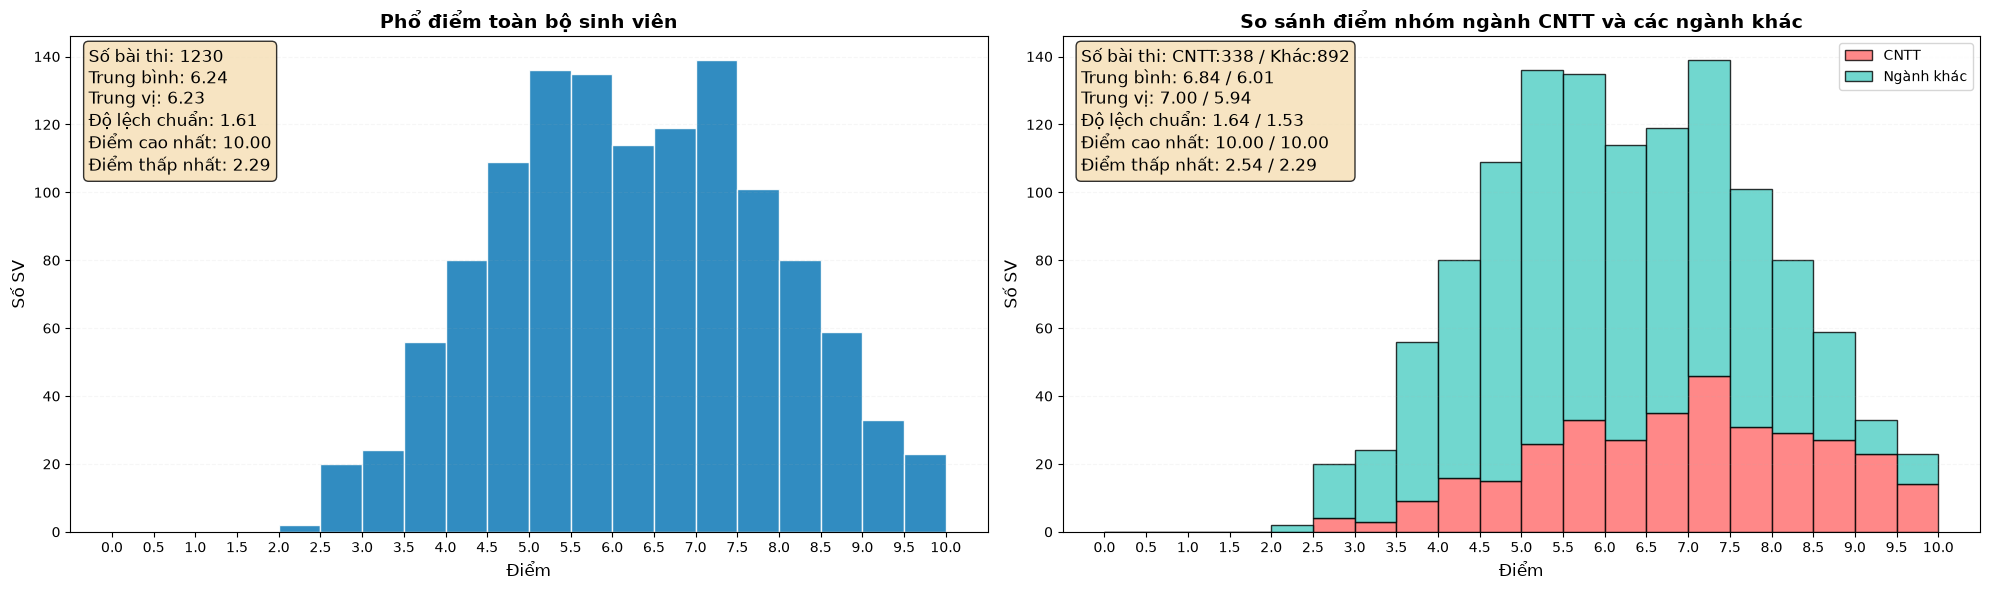

In [26]:

# Tạo subplot với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
# Thiết lập bins cho các khoảng điểm
bins = np.arange(0, 10 + 0.25, 0.5)

# Biểu đồ 1: Phổ điểm toàn bộ cột Grade
axes[0].hist(grade_df['Grade'], bins=bins, edgecolor='white', alpha=0.9, color='#1a80bb')
axes[0].set_title('Phổ điểm toàn bộ sinh viên', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Điểm', fontsize=12)
axes[0].set_ylabel('Số SV', fontsize=12)
axes[0].set_xticks(bins)
axes[0].grid(axis='y', linestyle='--', alpha=0.1)

# Tính các thống kê
mean_grade = grade_df['Grade'].mean()
median_grade = grade_df['Grade'].median()
std_grade = grade_df['Grade'].std()

# Thêm thông tin thống kê vào biểu đồ
stats_text = f'Số bài thi: {len(grade_df['Grade'])}\nTrung bình: {mean_grade:.2f}\nTrung vị: {median_grade:.2f}\nĐộ lệch chuẩn: {std_grade:.2f}\nĐiểm cao nhất: {grade_df['Grade'].max():.2f}\nĐiểm thấp nhất: {grade_df['Grade'].min():.2f}'
axes[0].text(0.02, 0.98, stats_text, transform=axes[0].transAxes, 
             verticalalignment='top', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Biểu đồ 2 (stacked histogram): Phổ điểm nhóm ngành của CNTT so với các ngành khác
# Tạo dữ liệu cho stacked histogram
# Filter grades of IT group
grades_cntt = grade_df[grade_df['MajorGroup'] == 'IT']['Grade']
# Filter grades of Non-IT group
grades_others = grade_df[grade_df['MajorGroup'] == 'Non-IT']['Grade']
# Tạo data bins chung cho cả hai nhóm
# bins = np.linspace(0, 10, 21)  
bins = np.arange(0, 10.5, 0.5)  

# Vẽ stacked histogram
axes[1].hist([grades_cntt, grades_others], bins=bins, stacked=True, 
             label=['CNTT', 'Ngành khác'], 
             color=['#FF6B6B', '#4ECDC4'], edgecolor='black', alpha=0.8)

axes[1].set_title('So sánh điểm nhóm ngành CNTT và các ngành khác', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Điểm', fontsize=12)
axes[1].set_ylabel('Số SV', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].set_xticks(bins)
axes[1].grid(axis='y', linestyle='--', alpha=0.1)

# Tính thống kê cho từng nhóm
cntt_mean = grades_cntt.mean()
other_mean = grades_others.mean()
cntt_count = len(grades_cntt)
other_count = len(grades_others)
cntt_median = grades_cntt.median()
other_median = grades_others.median()
cntt_std = grades_cntt.std()
other_std = grades_others.std()
cntt_max = grades_cntt.max()
other_max = grades_others.max()
cntt_min = grades_cntt.min()
other_min = grades_others.min()

# Thêm thông tin thống kê vào biểu đồ 2
stats_text2 = f'Số bài thi: CNTT:{cntt_count} / Khác:{other_count}\nTrung bình: {cntt_mean:.2f} / \
{other_mean:.2f}\nTrung vị: {cntt_median:.2f} / {other_median:.2f}\nĐộ lệch chuẩn: {cntt_std:.2f} / \
{other_std:.2f}\nĐiểm cao nhất: {cntt_max:.2f} / {other_max:.2f}\nĐiểm thấp nhất: {cntt_min:.2f} / {other_min:.2f}'
axes[1].text(0.02, 0.98, stats_text2, transform=axes[1].transAxes, 
             verticalalignment='top', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Điều chỉnh layout
plt.tight_layout()
# Lưu biểu đồ thành file
plt.savefig('figs/final-stats.pdf')
# Hiển thị biểu đồ
plt.show()

## Line plot

In [ ]:
# Load data of gold prices and visualize the price trend over time
# Data source: https://datahub.io/core/gold-prices

